In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading cleaned dataset
traffic_df = pd.read_csv("../data/processed/traffic_cleaned.csv")

In [3]:
# converting timestamp
traffic_df['timestamp'] = pd.to_datetime(traffic_df['timestamp'])

In [4]:
traffic_df.head()

,traffic_id,timestamp,day,hour,weather,area_type,traffic_density,car_count,bike_count,truck_count,signal_waiting_time_seconds
0,1,2025-09-26 17:03:00,Friday,17,Foggy,Industrial,Medium,32,46,9,37
1,2,2025-01-02 01:33:00,Thursday,1,Foggy,Residential,Low,18,17,5,5
2,3,2025-09-03 04:37:00,Wednesday,4,Clear,School Zone,Low,7,27,5,10
3,4,2025-11-18 01:30:00,Tuesday,1,Rainy,Commercial,Medium,34,49,13,46
4,5,2025-01-15 06:04:00,Wednesday,6,Foggy,Industrial,Low,5,18,5,16


In [5]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   traffic_id                   15000 non-null  int64         
 1   timestamp                    15000 non-null  datetime64[ns]
 2   day                          15000 non-null  object        
 3   hour                         15000 non-null  int64         
 4   weather                      15000 non-null  object        
 5   area_type                    15000 non-null  object        
 6   traffic_density              15000 non-null  object        
 7   car_count                    15000 non-null  int64         
 8   bike_count                   15000 non-null  int64         
 9   truck_count                  15000 non-null  int64         
 10  signal_waiting_time_seconds  15000 non-null  int64         
dtypes: datetime64[ns](1), int64(6), object(4)

In [6]:
traffic_df.describe()

,traffic_id,timestamp,hour,car_count,bike_count,truck_count,signal_waiting_time_seconds
count,15000.000000,15000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2025-07-01 11:54:03.748000,11.544600,35.63300,49.676600,10.370133,44.840533
min,1.000000,2025-01-01 00:14:00,0.000000,5.00000,10.000000,0.000000,5.000000
25%,3750.750000,2025-03-31 22:00:30,6.000000,14.00000,22.000000,3.000000,14.000000
50%,7500.500000,2025-07-01 01:08:30,12.000000,26.00000,39.000000,7.000000,29.000000
75%,11250.250000,2025-09-30 11:00:30,18.000000,46.00000,65.250000,14.000000,55.000000
max,15000.000000,2025-12-31 23:02:00,23.000000,120.00000,150.000000,40.000000,180.000000
std,4330.271354,NaN,6.903892,29.05259,35.872962,10.072479,43.892298


## Traffic Density Distribution

In [9]:
traffic_df['traffic_density'].value_counts()

traffic_density
Low       6261
Medium    5719
High      3020
Name: count, dtype: int64

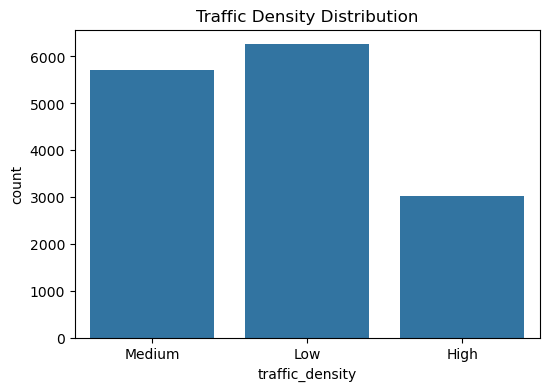

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=traffic_df, x='traffic_density')
plt.title("Traffic Density Distribution")
plt.show()

## Traffic by Area Type

In [10]:
traffic_df['area_type'].value_counts()

area_type
Commercial     3078
Highway        3013
School Zone    2989
Industrial     2984
Residential    2936
Name: count, dtype: int64

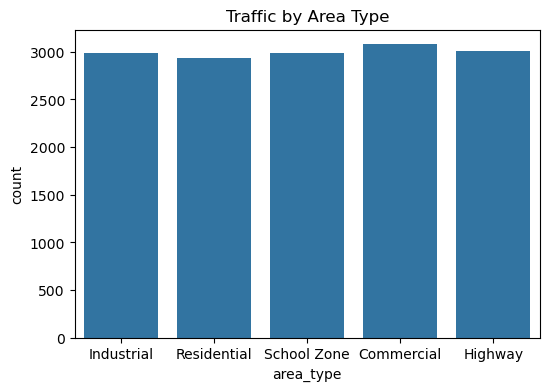

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=traffic_df, x='area_type')
plt.title("Traffic by Area Type")
plt.show()

## Peak Traffic Hours

In [12]:
traffic_df.groupby('hour').size()

hour
0     586
1     631
2     638
3     618
4     635
5     579
6     641
7     612
8     612
9     644
10    611
11    675
12    619
13    638
14    607
15    623
16    657
17    605
18    645
19    579
20    653
21    650
22    633
23    609
dtype: int64

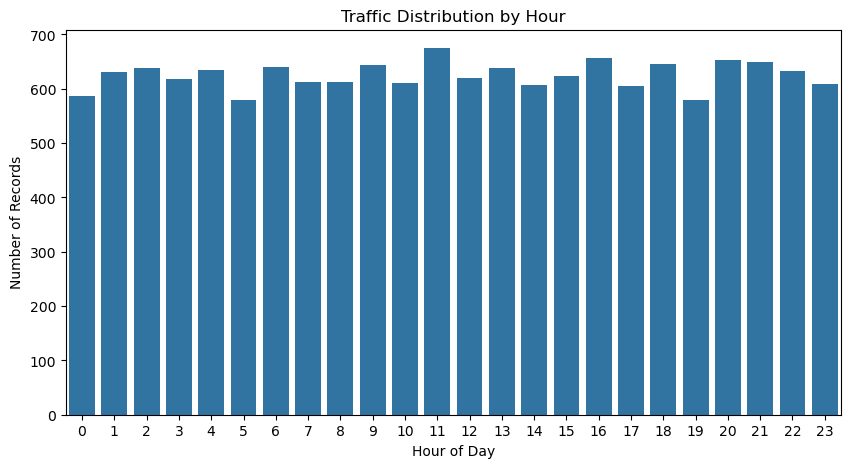

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(data=traffic_df, x='hour')
plt.title("Traffic Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Records")
plt.show()

## Vehicle Count Distribvtion

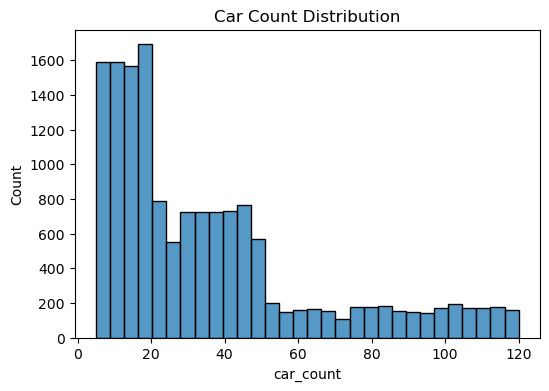

In [16]:
# cars
plt.figure(figsize=(6,4))
sns.histplot(traffic_df['car_count'], bins=30)
plt.title("Car Count Distribution")
plt.show()

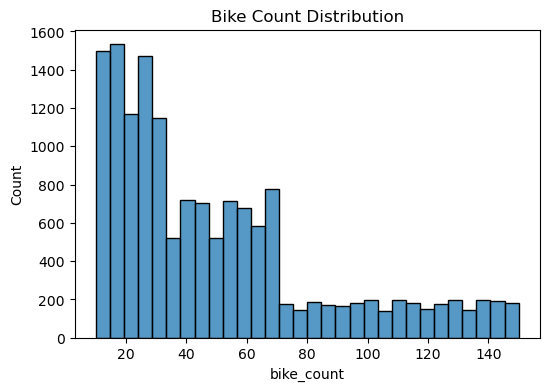

In [17]:
# bikes
plt.figure(figsize=(6,4))
sns.histplot(traffic_df['bike_count'], bins=30)
plt.title("Bike Count Distribution")
plt.show()

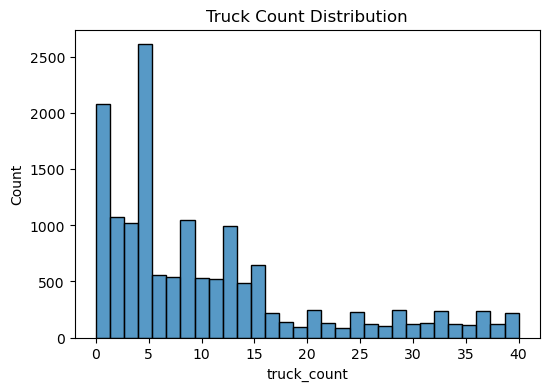

In [18]:
# trucks
plt.figure(figsize=(6,4))
sns.histplot(traffic_df['truck_count'], bins=30)
plt.title("Truck Count Distribution")
plt.show()

## Averge Vehicle Count

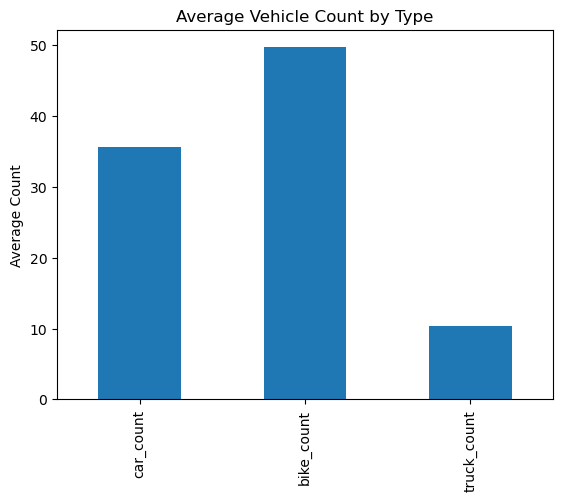

In [19]:
vehicle_means = traffic_df[['car_count','bike_count','truck_count']].mean()

vehicle_means.plot(kind='bar')
plt.title("Average Vehicle Count by Type")
plt.ylabel("Average Count")
plt.show()

## Signal Waiting Time Distribution

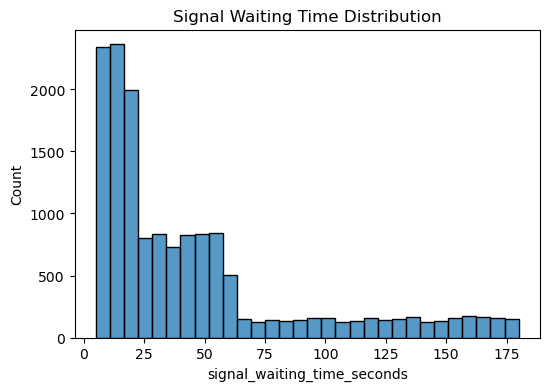

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(traffic_df['signal_waiting_time_seconds'], bins=30)
plt.title("Signal Waiting Time Distribution")
plt.show()

## Traffic Density by Area Type

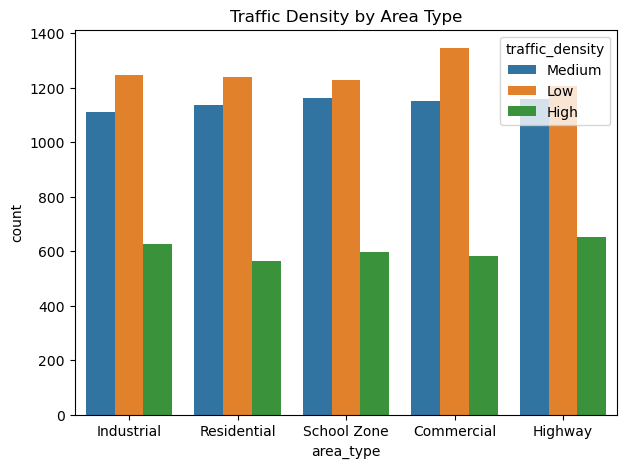

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(data=traffic_df, x='area_type', hue='traffic_density')
plt.title("Traffic Density by Area Type")
plt.show()